# Notebook 03: The Undisputed Production Big Three & DART
## Comprehensive Mathematical Foundations of XGBoost 2.x, LightGBM & CatBoost

---

### 1. Executive Intuition & Conceptual Roadmap

#### The Evolution: How Did We Get Here?
In **Notebook 02**, we learned that Gradient Boosting is gradient descent in function space. But classical GBDT had severe limitations in high-throughput enterprise systems:
1. It only used 1st-order gradients (slow convergence).
2. It grew rigid depth-wise trees (wasted computation on uninformative leaves).
3. It had no native way to handle categorical data (like Arabic governorates or payment methods) without causing target leakage.

The industry solved these bottlenecks through **The Big Three**:
* **XGBoost (The Mathematician)**: Introduced 2nd-order Taylor expansions (Newton-Raphson in function space) and exact $L_1/L_2$ leaf regularization.
* **LightGBM (The Engineer)**: Introduced **Leaf-Wise tree growth**, **GOSS** sampling, and **DART** (Tree Dropout) for extreme velocity on massive tabular datasets.
* **CatBoost (The Statistician)**: Introduced **Oblivious (symmetric) trees** and **Ordered Boosting** to eliminate target leakage on high-cardinality categorical data.

```mermaid
graph TD
    subgraph XGBoost [XGBoost: 2nd-Order Newton Optimization]
        X1[1st Order Gradient: g_i] & X2[2nd Order Hessian: h_i] --> XOpt[Exact Optimal Leaf Weight: -G / H + lambda]
        XOpt --> XGain[Analytical Split Gain Formula]
    end
    subgraph LightGBM [LightGBM: Leaf-Wise & GOSS]
        L1[Sort instances by gradient] --> L2[Keep Top a% Large Gradients]
        L2 --> L3[Randomly Sample b% Small Gradients]
        L3 --> LBest[Split Single Best Leaf Globally]
    end
    subgraph CatBoost [CatBoost: Oblivious Trees & Permutations]
        C1[Random Permutations sigma] --> C2[Ordered Target Encoding: No Leakage]
        C2 --> CSymm[Oblivious Symmetric Tree: Hardware Bitwise Lookup]
    end
```

Let's break down this entire derivation step-by-step. 

At its core, this derivation answers two fundamental questions that **every** decision tree algorithm must solve:
1. **What value should a leaf predict?** ($w_j^*$)
2. **How do we decide if a split is worth making?** ($\text{Gain}$)

XGBoost solves both in one shot using **Newton-Raphson (2nd-order Taylor approximation)**.

---

### The Big Picture: Why 2nd-Order?

* **Classical Gradient Boosting (Friedman)**: Only looks at the **1st derivative** (the slope / direction of error). To determine how far to step, it either uses a constant learning rate or does an expensive 1D line-search.
* **XGBoost**: Looks at **both the 1st derivative ($g_i$, slope)** and the **2nd derivative ($h_i$, curvature)**. Because it knows the curvature, it can jump **directly to the exact minimum of the quadratic approximation in a single closed-form step**.

---

### Step 1: 2nd-Order Taylor Approximation (The Setup)

When training tree number $t$, the objective is:
$$\mathcal{L}^{(t)} = \sum_{i=1}^n L\Big(y_i, \underbrace{\hat{y}_i^{(t-1)}}_{\text{old prediction}} + \underbrace{f_t(x_i)}_{\text{new tree prediction}}\Big) + \Omega(f_t)$$

Think of Taylor's formula around a starting point $x$:
$$f(x + \Delta x) \approx f(x) + f'(x)\Delta x + \frac{1}{2}f''(x)(\Delta x)^2$$

Here:
* $x \longrightarrow \hat{y}_i^{(t-1)}$ (where the model already stands)
* $\Delta x \longrightarrow f_t(x_i)$ (the step the new tree is going to take)

Applying this to our loss function:
$$L(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)) \approx L(y_i, \hat{y}_i^{(t-1)}) + g_i \cdot f_t(x_i) + \frac{1}{2} h_i \cdot f_t^2(x_i)$$

where:
* $g_i = \frac{\partial L}{\partial \hat{y}}$ : **1st derivative (Gradient)** — tells us the direction of error.
* $h_i = \frac{\partial^2 L}{\partial \hat{y}^2}$ : **2nd derivative (Hessian)** — tells us the curvature (how fast the gradient is changing / confidence).

#### Why can we drop $L(y_i, \hat{y}_i^{(t-1)})$?
Because $\hat{y}_i^{(t-1)}$ comes from previous trees that are already frozen! It is a **constant number** with respect to the new tree $f_t$. In optimization, adding or removing a constant doesn't change where the minimum lies:
$$\widetilde{\mathcal{L}}^{(t)} = \sum_{i=1}^{n} \left[ g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i) \right] + \gamma T + \frac{1}{2}\lambda \sum_{j=1}^T w_j^2$$

---

### Step 2: From Data Points to Leaves (The Grouping Trick)

A decision tree is simply a partition of the dataset into $T$ separate buckets (leaf nodes).
Every sample $i$ that lands in leaf $j$ gets assigned the **exact same output**:
$$f_t(x_i) = w_j$$

Instead of optimizing $n$ individual values (one per row), we only have to find $T$ numbers (one per leaf).

Let $I_j$ be the group of samples landing in leaf $j$. We group the sums:
$$\widetilde{\mathcal{L}}^{(t)} = \sum_{j=1}^{T} \left[ \left(\sum_{i \in I_j} g_i\right) w_j + \frac{1}{2} \left(\sum_{i \in I_j} h_i + \lambda\right) w_j^2 \right] + \gamma T$$

To make the notation clean, define:
* **$G_j = \sum_{i \in I_j} g_i$**: Sum of all gradients in leaf $j$ (total residual push).
* **$H_j = \sum_{i \in I_j} h_i$**: Sum of all hessians in leaf $j$ (total curvature / effective sample weight).

Now each leaf is completely independent:
$$\widetilde{\mathcal{L}}^{(t)} = \sum_{j=1}^{T} \underbrace{\left[ G_j w_j + \frac{1}{2}(H_j + \lambda) w_j^2 \right]}_{\text{Loss contribution of leaf } j} + \gamma T$$

---

### Step 3: Finding the Optimal Prediction $w_j^*$ (High School Calculus)

For any single leaf $j$, look at its cost function:
$$f(w_j) = \frac{1}{2}(H_j + \lambda) w_j^2 + G_j w_j$$

This is simply a standard upward-opening parabola: $f(w) = A w^2 + B w$, where:
* $A = \frac{1}{2}(H_j + \lambda)$
* $B = G_j$

The minimum of $A w^2 + B w$ is where the derivative equals zero:
$$\frac{df}{dw_j} = (H_j + \lambda) w_j + G_j = 0 \implies \mathbf{w_j^* = -\frac{G_j}{H_j + \lambda}}$$

#### Intuition of $w_j^* = -\frac{G_j}{H_j + \lambda}$:
1. **The negative sign ($-$):** If $G_j > 0$ (predictions were generally too high), $w_j^*$ must be negative to pull them down.
2. **The denominator ($H_j + \lambda$):** 
   - If a leaf has many samples with high certainty, $H_j$ is large, so $w_j^*$ is small and conservative.
   - If a leaf has very few samples ($H_j \approx 0$), $w_j^*$ could explode to infinity! **$\lambda$ acts as an anchor ($L_2$ regularization)** that shrinks the prediction toward zero when sample evidence is weak.

---

### Step 4: The Minimum Loss & The Split Gain Formula

If we plug the optimal value $w_j^* = -\frac{G_j}{H_j + \lambda}$ back into the leaf loss:
$$\text{Cost}_j = G_j \left(-\frac{G_j}{H_j + \lambda}\right) + \frac{1}{2}(H_j + \lambda) \left(-\frac{G_j}{H_j + \lambda}\right)^2 = -\frac{G_j^2}{H_j + \lambda} + \frac{1}{2}\frac{G_j^2}{H_j + \lambda} = \mathbf{-\frac{1}{2} \frac{G_j^2}{H_j + \lambda}}$$

Summing across all $T$ leaves:
$$\widetilde{\mathcal{L}}^{(t)} = -\frac{1}{2} \sum_{j=1}^T \frac{G_j^2}{H_j + \lambda} + \gamma T$$
*Notice: lower is better (more negative means better fit).*

#### Evaluating a Split:
Suppose we are at a leaf node and thinking of splitting it into **Left ($L$)** and **Right ($R$)**:

* **Before Split (Single Node)**:
  All samples are together. Total gradient is $G_L + G_R$, total hessian is $H_L + H_R$. 
  $$\text{Score}_{\text{before}} = -\frac{1}{2} \frac{(G_L + G_R)^2}{H_L + H_R + \lambda} + \gamma$$

* **After Split (Two Nodes)**:
  Now we have 2 leaves, so penalty increases by $2\gamma$:
  $$\text{Score}_{\text{after}} = -\frac{1}{2} \left[ \frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} \right] + 2\gamma$$

* **The Gain (How much does loss drop?)**:
  $$\text{Gain} = \text{Score}_{\text{before}} - \text{Score}_{\text{after}}$$
  $$\mathbf{\text{Gain} = \frac{1}{2} \left[ \underbrace{\frac{G_L^2}{H_L + \lambda}}_{\text{Left quality}} + \underbrace{\frac{G_R^2}{H_R + \lambda}}_{\text{Right quality}} - \underbrace{\frac{(G_L + G_R)^2}{H_L + H_R + \lambda}}_{\text{Combined parent quality}} \right] - \gamma}$$

---

### Summary Table of Parameters

| Symbol | Mathematical Role | Machine Learning Intuition |
| :--- | :--- | :--- |
| **$g_i$** | 1st derivative $\frac{\partial L}{\partial \hat{y}}$ | Direction and magnitude of the residual error for sample $i$. |
| **$h_i$** | 2nd derivative $\frac{\partial^2 L}{\partial \hat{y}^2}$ | Curvature / confidence (for cross-entropy, $h_i = p_i(1 - p_i)$). |
| **$\lambda$** | Added to denominator ($H_j + \lambda$) | **$L_2$ regularization**: prevents leaf weights from exploding on small leaves. |
| **$\gamma$** | Subtracted from Gain | **Pruning threshold**: A split is rejected unless the reduction in loss exceeds $\gamma$. |

#### B. LightGBM: Leaf-Wise Growth, GOSS & DART

LightGBM (*Light Gradient Boosting Machine*, Microsoft Research, 2017) revolutionized tabular learning by tackling the two fundamental bottlenecks of GBDTs: **tree growth inefficiency** and **sample scanning overhead**. It introduced three architectural breakthroughs:

```mermaid
graph TD
    subgraph Innovations["LightGBM Core Innovations"]
        A["1. Leaf-Wise (Best-First) Growth<br/>Split highest-gain leaf globally"] 
        B["2. GOSS (Gradient Sampling)<br/>Keep large |g_i|, sample small |g_i|"]
        C["3. DART (Tree Dropout)<br/>Drop random trees to stop over-specialization"]
    end
```

---

##### 1. Leaf-Wise (Best-First) vs. Level-Wise (Depth-First) Growth

Traditional algorithms (like standard XGBoost and classical Random Forest) grow trees **level-wise**, whereas LightGBM grows trees **leaf-wise**:

```
Level-Wise (Breadth-First / Depth-Wise):
               [ Root ]
              /        \
           [Node]    [Node]        <-- Splits all nodes at Depth 1
           /    \    /    \
          L1    L2  L3    L4       <-- Splits all nodes at Depth 2 (Strictly balanced)

Leaf-Wise (Best-First):
               [ Root ]
              /        \
            L1       [Node]        <-- Only splits the leaf yielding MAX GAIN
                    /      \
                   L2     [Node]   <-- Continues splitting the highest-gain leaf
                         /      \
                        L3      L4  (Asymmetric, dives deep where error is concentrated)
```

| Dimension | Level-Wise (Depth-First) | Leaf-Wise (Best-First) |
| :--- | :--- | :--- |
| **Splitting Strategy** | Splits all nodes at current depth $d$ | Searches all leaves globally; splits the **single leaf with highest Gain** |
| **Tree Balance** | Strictly symmetric / balanced | Highly asymmetric |
| **Loss Reduction per Split** | Low to moderate (wastes compute splitting low-gain leaves) | **Maximum possible** (greedy descent on the steepest loss gradient) |
| **Primary Hyperparameter** | `max_depth` | `num_leaves` ($2^{\text{depth}}$ is the upper bound) |
| **Overfitting Risk** | Lower (inherent depth regularization) | Higher on small datasets; requires `num_leaves` or `min_child_samples` |

> 💡 **Why Leaf-Wise minimizes loss faster**: For a fixed budget of $K$ splits, Leaf-Wise is guaranteed to achieve a lower (or equal) training loss than Level-Wise because it greedily picks the top-$K$ global splits across the entire frontier, rather than forcing splits on barren branches.

---

##### 2. GOSS (Gradient-based One-Side Sampling)

Traditional GBDTs compute split gain using all $N$ data points. Uniform random sampling (e.g., `subsample=0.5`) speeds up training, but discards critical hard examples and degrades accuracy.

**GOSS Key Insight**: The absolute gradient $|g_i|$ serves as an exact proxy for **data point error**:
* Large $|g_i|$: Model is making large errors $\to$ instance is **under-trained** $\to$ carries rich information.
* Small $|g_i|$: Model has already fit this instance well $\to$ low training error $\to$ contributes little to split finding.

###### The GOSS Algorithm:
1. Sort all $N$ training points in descending order by $|g_i|$.
2. Keep the top subset $A$ of size $a \times N$ containing the largest gradients ($a \in [0, 1]$, e.g., $a = 0.20$).
3. From the remaining subset $A^c$ of size $(1 - a)N$, randomly sample a subset $B$ of size $b \times (1 - a)N$ ($b \in [0, 1]$, e.g., $b = 0.10$).
4. To compute the split gain on the reduced sample $A \cup B$, amplify the small-gradient instances by an **inflation weight** $w = \frac{1 - a}{b}$:
   $$\widetilde{G}_j = \sum_{i \in I_j \cap A} g_i + \frac{1 - a}{b} \sum_{i \in I_j \cap B} g_i$$

###### Mathematical Proof: GOSS is an Unbiased Estimator
Let $\mathbb{I}_{i \in B}$ be an indicator variable where $\mathbb{I}_{i \in B} = 1$ if sample $i$ is sampled into $B$, and $0$ otherwise.
Since each sample in $A^c$ has uniform sampling probability $P(i \in B) = b$:
$$\mathbb{E}[\mathbb{I}_{i \in B}] = b$$

Taking the expected value of the GOSS estimated gradient sum $\widetilde{G}_j$:
$$\mathbb{E}[\widetilde{G}_j] = \mathbb{E}\left[ \sum_{i \in I_j \cap A} g_i + \frac{1 - a}{b} \sum_{i \in I_j \cap A^c} g_i \cdot \mathbb{I}_{i \in B} \right]$$

Using linearity of expectation (since $A$ is deterministic and only $B$ is random):
$$\mathbb{E}[\widetilde{G}_j] = \sum_{i \in I_j \cap A} g_i + \frac{1 - a}{b} \sum_{i \in I_j \cap A^c} g_i \cdot \mathbb{E}[\mathbb{I}_{i \in B}]$$
$$\mathbb{E}[\widetilde{G}_j] = \sum_{i \in I_j \cap A} g_i + \frac{1 - a}{b} \sum_{i \in I_j \cap A^c} g_i \cdot b$$
$$\mathbb{E}[\widetilde{G}_j] = \sum_{i \in I_j \cap A} g_i + (1 - a)\sum_{i \in I_j \cap A^c} g_i = \sum_{i \in I_j} g_i = G_j \quad \blacksquare$$

> 🎯 **Theorem Result**: GOSS provides an **unconditionally unbiased gradient estimator** while evaluating only $(a + b) \times 100\%$ of the data (e.g., $20\% + 10\% = 30\%$ of samples), achieving a **$\approx 3\times$ speedup with near-zero loss in accuracy**.

---

##### 3. DART: Dropouts meet Multiple Additive Regression Trees

###### The Fundamental Flaw of Standard GBDT: Over-Specialization
In classical boosting, each tree $t$ is fit to the residual of the ensemble of all prior trees:
$$r_i^{(t)} = y_i - \sum_{k=1}^{t-1} f_k(x_i)$$
* Trees built in the first $10-20$ iterations make **massive, macro-level predictions** that dictate most of the final score.
* Trees built at iteration $500+$ only make tiny micro-adjustments fitting residual noise.
* If an early tree makes a split on a spurious feature, subsequent trees spend their entire capacity trying to compensate for that error. This greedy path-dependency hurts test generalization.

###### The DART Solution (Vinayak & Gilad-Bachrach, 2015)
DART injects the regularization principle of **Deep Learning Dropout** into decision tree ensembles:

```
Iteration m:
1. Randomly DROP a subset D of existing trees with probability p_drop:
   Dropped Trees: { T_2, T_5, T_7 }   (temporarily disabled)

2. Calculate residuals using ONLY the surviving trees:
   r_i = y_i - Σ_{k ∉ D} f_k(x_i)

3. Fit new tree T_m to these larger, more informative residuals!

4. Apply Normalization Shrinkage:
   - Scale new tree T_m by:        1 / (|D| + 1)
   - Scale dropped trees T_d by:   |D| / (|D| + 1)
```

###### Why DART Prevents Overfitting:
1. **No Single Dominant Tree**: Because any tree might be dropped at any iteration, the model is forbidden from relying disproportionately on any single early branch.
2. **True Ensemble Behavior**: Each tree is trained against a variable sub-ensemble, forcing all trees to learn generalizable, self-sufficient functional representations.

> ⚠️ **Critical DART Production Caveats**:
> 1. **No Early Stopping**: Because trees are dropped randomly, the validation loss fluctuates non-monotonically between iterations. Early stopping will trigger prematurely.
> 2. **Inference / Prediction**: At test time, all trees are active (scaled appropriately), exactly like evaluating a neural network with dropout turned off.
```

#### C. CatBoost: Oblivious Trees & Ordered Target Statistics

CatBoost (*Categorical Boosting*, Yandex Research, Prokhorenkova et al., NeurIPS 2018) was engineered to solve two pervasive flaws in gradient boosting: **prediction shift (target leakage)** when encoding categorical features, and **inference latency** caused by irregular decision tree branch structures.

```mermaid
graph TD
    subgraph Pillars["CatBoost Core Architecture"]
        P1["1. Oblivious (Symmetric) Trees<br/>Single split per level — 0 branch mispredictions"]
        P2["2. Ordered Target Statistics<br/>Permutation-based target encoding without leakage"]
        P3["3. Ordered Boosting<br/>Unbiased gradient step estimation"]
    end
```

---

##### 1. Oblivious (Symmetric) Decision Trees

Unlike standard decision trees (CART, XGBoost, LightGBM) where every node chooses its own unique feature and split threshold, an **Oblivious Tree** enforces a strict structural constraint: **all nodes at depth $d$ share the exact same split criterion $(f_d, \theta_d)$**.

```
Standard Asymmetric Tree (XGBoost/LightGBM):
                  [Age > 30?]
                 /           \
        [Income > 50k?]     [City == Cairo?]      <-- Different features at same depth!
           /        \           /         \
         L1          L2       L3           L4     (Irregular memory layout, branch mispredictions)

Oblivious (Symmetric) Tree (CatBoost):
                  [Age > 30?]                     <-- Split Criterion 0
                 /           \
       [Income > 50k?]     [Income > 50k?]        <-- Split Criterion 1 (Identical across depth 1)
           /        \           /         \
         L0          L1       L2           L3     (Uniform 2^D leaves, perfect bitwise evaluation)
```

###### Mathematical Formulation & Bitwise Evaluation
For a tree of depth $D$, we have exactly $D$ binary predicate questions:
$$b_d(x) = \mathbb{I}\left(x_{f_d} > \theta_d\right) \in \{0, 1\} \quad \text{for } d \in \{0, 1, \dots, D - 1\}$$

Evaluating an instance $x$ does **not** require traversing pointer-based node graphs. Instead, the leaf index $k \in \{0, 1, \dots, 2^D - 1\}$ is determined via **direct bitwise shifting**:
$$\mathbf{\text{LeafIndex}(x) = \sum_{d=0}^{D-1} b_d(x) \cdot 2^d = (b_{D-1} \ll (D-1)) \mid \dots \mid (b_1 \ll 1) \mid b_0}$$

| Architectural Advantage | Deep Technical Impact |
| :--- | :--- |
| **Zero Branch Mispredictions** | CPU hardware branch predictors never stall; evaluation contains no conditional jumps (`if/else`), only vector comparisons and bitwise ORs. |
| **SIMD & GPU Parallelism** | An entire batch of 32 or 64 instances can be evaluated simultaneously within a single CPU AVX-512 register or GPU warp. |
| **Built-in Regularization** | Enforcing symmetry limits the hypothesis search space to $O(F^D)$ rather than $O(F^{2^D - 1})$, acting as a strong structural prior that prevents trees from memorizing localized sample noise. |
| **Lookup Table Inference** | Model weights can be exported as a flat lookup array: `prediction = leaf_weights[LeafIndex]`. |

---

##### 2. Ordered Target Statistics (Solving Target Leakage)

###### The Danger of Naive Target Encoding
When dealing with high-cardinality categorical features (e.g., thousands of unique product IDs, customer zip codes, or Arabic cities like `القاهرة`, `الرياض`), one-hot encoding causes feature explosion. 

Standard **Mean Target Encoding** replaces category $c$ with the sample mean of the target variable $y$:
$$\hat{x}_{i} = \frac{\sum_{j=1}^N \mathbb{I}(x_j = x_i) \cdot y_j}{\sum_{j=1}^N \mathbb{I}(x_j = x_i)}$$

* **The Fatal Flaw (Target Leakage)**: Instance $i$'s own label $y_i$ directly contaminates its feature representation $\hat{x}_i$. 
* **The Consequence**: If a rare category appears only once with $y=1$, the model learns $\hat{x}_i = 1.0$, creating a perfect shortcut. At test time, this feature has zero predictive validity, leading to catastrophic overfitting (**Conditional Shift**).

###### CatBoost's Solution: Virtual Time & Random Permutations
CatBoost eliminates target leakage by introducing the concept of **causal time ordering**:
1. Draw a random permutation $\sigma = (\sigma_1, \sigma_2, \dots, \sigma_N)$ of all training samples.
2. An instance $i$ is only allowed to see target values of samples that appear **strictly before it in the permutation** ($\sigma(j) < \sigma(i)$).

###### The Mathematical Formula (With Bayesian Laplace Smoothing):
$$\mathbf{\hat{x}_{i, \text{cat}} = \frac{\sum_{j: \sigma(j) < \sigma(i)} \mathbb{I}(x_j = x_i) \cdot y_j + a \cdot P}{\sum_{j: \sigma(j) < \sigma(i)} \mathbb{I}(x_j = x_i) + a}}$$

where:
* **$P$ (Global Prior Mean)**: The overall dataset target average: $P = \frac{1}{N} \sum_{k=1}^N y_k$.
* **$a > 0$ (Smoothing Weight)**: A Bayesian Dirichlet prior parameter (typically $a = 1.0$ or $a = 2.0$) that pulls low-frequency categories toward the global prior $P$.
* **$\mathbb{I}(x_j = x_i)$**: An indicator matching instances with the exact same category.

> 🛡️ **Mathematical Guarantee**: Because $\sigma(j) < \sigma(i)$ strictly excludes $j = i$, **$y_i$ is never present in the numerator or denominator**. Target leakage is mathematically impossible!

###### Multi-Permutation Ensemble
Using a single permutation would make early instances have high-variance target estimates (since they only see a few preceding points). 
To neutralize this variance, **CatBoost generates multiple independent random permutations** ($\sigma^{(1)}, \sigma^{(2)}, \dots, \sigma^{(S)}$, typically $S=4$) across boosting iterations, updating target statistics dynamically at each tree split.

---

##### 3. Ordered Boosting (Combating Prediction Shift)

In classical gradient boosting, gradients $g_i$ are calculated using a model $F^{(t-1)}$ that was trained on the exact same dataset containing $x_i$. This causes the distribution of $g(x_i, y_i) \mid x_i$ to shift from the true conditional gradient distribution on unseen data (**Prediction Shift**).

```
Ordered Boosting Principle:
To compute the gradient for sample x_i, use a sub-model M_i
that was trained SOLELY on samples preceding x_i in permutation σ:
                 g_i = - [ ∂L(y_i, M_i(x_i)) / ∂M_i(x_i) ]
```

By guaranteeing that neither the target statistic nor the gradient computation ever includes information from the instance itself, CatBoost achieves the **most statistically honest validation and generalization properties of any tree algorithm**.
```

In [1]:
# ── Environment Setup ─────────────────────────────────────────────────────────
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cur_dir   = os.path.abspath(os.getcwd())
trees_dir = os.path.abspath(os.path.join(cur_dir, '..')) if os.path.basename(cur_dir) == 'notebooks' else cur_dir
repo_root = os.path.abspath(os.path.join(trees_dir, '..'))
for p in [trees_dir, repo_root]:
    if p not in sys.path:
        sys.path.insert(0, p)

try:
    from trees.utils import (
        print_hardware_summary, load_dataset, prepare_features,
        evaluate_multiclass_model, evaluate_model_splits,
        plot_confusion_matrix_20, plot_metrics_comparison,
        DEPARTMENTS_EN, CUDA_AVAILABLE
    )
except ImportError:
    from utils import (
        print_hardware_summary, load_dataset, prepare_features,
        evaluate_multiclass_model, evaluate_model_splits,
        plot_confusion_matrix_20, plot_metrics_comparison,
        DEPARTMENTS_EN, CUDA_AVAILABLE
    )

print_hardware_summary()
device_target = 'cuda' if CUDA_AVAILABLE else 'cpu'
print(f"CUDA Acceleration Target: {device_target}")

HARDWARE & EXECUTION ENVIRONMENT
System RAM               : 15.7 GB
Intel Extension (oneDAL) : Not Installed
CUDA Available           : True
GPU Model                : NVIDIA GeForce RTX 2050
VRAM Capacity            : 4.00 GB (RTX 2050 Budget)
CUDA Acceleration Target: cuda


In [22]:
from sklearn.model_selection import train_test_split

# Load 50,000 samples — uses cached leak-free parquet if available
df = load_dataset(sample_rows=300_000, force_regenerate=True)
X_raw, y, cat_cols, num_cols = prepare_features(df)

# Convert categoricals to pandas 'category' dtype
# XGBoost 3.0 + enable_categorical=True handles this natively (no ordinal encoding)
# LightGBM also handles 'category' dtype internally
for col in cat_cols:
    X_raw[col] = X_raw[col].astype('category')

# Leak-Free 70/10/20 Stratified Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.6667, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"Categorical columns: {cat_cols}")

[Data Generator] Clean, leak-free dataset generated & cached to: c:\Users\MSI\OneDrive\Desktop\work\AI-Data-Science-Lab\trees\data\ecommerce_20class_sample_50k.parquet
Train: 210,000 | Val: 29,997 | Test: 60,003
Categorical columns: ['governorate_ar', 'payment_method_ar', 'customer_tier_ar', 'shipping_status_ar', 'device_type_en', 'traffic_source_en', 'courier_en', 'fulfillment_hub_en']


### 3. Model 1: XGBoost 3.x on RTX 2050 GPU
We train XGBoost with 2nd-order Taylor optimization, `tree_method='hist'`, `enable_categorical=True`,
and native GPU acceleration with early stopping on the explicit validation set.

In [23]:
import xgboost as xgb
print(f"XGBoost version: {xgb.__version__}")

all_results = []

t0 = time.time()
xgb_model = xgb.XGBClassifier(
    n_estimators=300,             # Early stopping controls actual count
    learning_rate=0.08,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,                # L1 regularization
    reg_lambda=1.0,               # L2 regularization (denominator in leaf weight)
    tree_method='hist',
    device=device_target,
    enable_categorical=True,      # XGBoost 3.x handles pandas 'category' dtype natively
    early_stopping_rounds=20,
    eval_metric='mlogloss',
    verbosity=0,                  # Suppress XGBoost internal logs
    random_state=42
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False                 # Suppress per-round output
)
xgb_time = time.time() - t0

print(f"Best iteration: {xgb_model.best_iteration} / {xgb_model.n_estimators}")

xgb_metrics = evaluate_model_splits(
    xgb_model, X_train, y_train, X_val, y_val, X_test, y_test,
    model_name=f"XGBoost 3.x ({device_target.upper()})", train_time=xgb_time
)
all_results.append(xgb_metrics)

pd.DataFrame([xgb_metrics])[[
    'Model', 'Training Time (s)',
    'Train Accuracy', 'Val Accuracy', 'Top-1 Accuracy', 'Overfitting Gap', 'Macro F1-Score'
]]

XGBoost version: 3.0.0
Best iteration: 229 / 300


,Model,Training Time (s),Train Accuracy,Val Accuracy,Top-1 Accuracy,Overfitting Gap,Macro F1-Score
0,XGBoost 3.x (CUDA),166.879085,0.826795,0.735674,0.738713,0.091122,0.715526


### 4. Model 2: LightGBM (Standard GBDT vs. DART Tree Dropout)
We evaluate LightGBM's leaf-wise growth, followed by DART to demonstrate resistance to over-specialization.

> ⚠️ **Note**: DART does **not** support early stopping — it trains for the full `n_estimators` iterations.

In [24]:
import lightgbm as lgb
print(f"LightGBM version: {lgb.__version__}")

# ── 1. LightGBM Standard GBDT with early stopping ────────────────────────────
t0 = time.time()
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,             # Early stopping controls actual count
    learning_rate=0.08,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    device='cpu',
    random_state=42,
    verbose=-1
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=20, verbose=False),
        lgb.log_evaluation(period=0)    # silence per-round logs
    ]
)
lgb_time = time.time() - t0
print(f"GBDT best iteration: {lgb_model.best_iteration_}")

lgb_metrics = evaluate_model_splits(
    lgb_model, X_train, y_train, X_val, y_val, X_test, y_test,
    model_name="LightGBM (GBDT)", train_time=lgb_time
)
all_results.append(lgb_metrics)

# ── 2. LightGBM DART (Tree Dropout) — fixed iterations, no early stopping ────
t0 = time.time()
lgb_dart = lgb.LGBMClassifier(
    boosting_type='dart',
    n_estimators=100,             # Fixed — early stopping not supported with DART
    learning_rate=0.08,
    num_leaves=31,
    drop_rate=0.1,
    max_drop=5,
    random_state=42,
    verbose=-1
)
lgb_dart.fit(X_train, y_train)
dart_time = time.time() - t0

dart_metrics = evaluate_model_splits(
    lgb_dart, X_train, y_train, X_val, y_val, X_test, y_test,
    model_name="LightGBM (DART)", train_time=dart_time
)
all_results.append(dart_metrics)

pd.DataFrame(all_results)[[
    'Model', 'Training Time (s)',
    'Train Accuracy', 'Val Accuracy', 'Top-1 Accuracy',
    'Overfitting Gap', 'Top-3 Accuracy', 'Multi-Class Log-Loss'
]]

LightGBM version: 4.6.0
GBDT best iteration: 78


,Model,Training Time (s),Train Accuracy,Val Accuracy,Top-1 Accuracy,Overfitting Gap,Top-3 Accuracy,Multi-Class Log-Loss
0,XGBoost 3.x (CUDA),166.879085,0.826795,0.735674,0.738713,0.091122,0.902638,0.853122
1,LightGBM (GBDT),187.177347,0.778419,0.734240,0.736030,0.044179,0.901272,0.870908
2,LightGBM (DART),287.840800,0.755643,0.731173,0.735147,0.024470,0.899738,0.967242


### 5. Model 3: CatBoost on RTX 2050 GPU
CatBoost's oblivious trees are trained on the RTX 2050 GPU (`task_type='GPU'`) with native
categorical handling and Ordered Target Statistics to prevent leakage.

In [25]:
from catboost import CatBoostClassifier

# CatBoost GPU requires categorical features as strings (not pandas category dtype)
X_train_cat = X_train.copy()
X_val_cat   = X_val.copy()
X_test_cat  = X_test.copy()

for col in cat_cols:
    X_train_cat[col] = X_train_cat[col].astype(str)
    X_val_cat[col]   = X_val_cat[col].astype(str)
    X_test_cat[col]  = X_test_cat[col].astype(str)

cat_device = 'GPU' if CUDA_AVAILABLE else 'CPU'

t0 = time.time()
cat_model = CatBoostClassifier(
    iterations=300,               # Early stopping controls actual count
    learning_rate=0.08,
    depth=6,
    loss_function='MultiClass',
    task_type=cat_device,
    cat_features=cat_cols,
    random_seed=42,
    verbose=False
)
cat_model.fit(
    X_train_cat, y_train,
    eval_set=(X_val_cat, y_val),
    early_stopping_rounds=20,
    verbose=False
)
cat_time = time.time() - t0

print(f"CatBoost best iteration: {cat_model.best_iteration_}")

# CatBoost predict() returns shape (n,1) — flatten to 1D for compatibility
cat_pred       = cat_model.predict(X_test_cat).flatten()
cat_prob       = cat_model.predict_proba(X_test_cat)
cat_train_pred = cat_model.predict(X_train_cat).flatten()
cat_val_pred   = cat_model.predict(X_val_cat).flatten()

cat_metrics = evaluate_multiclass_model(
    f"CatBoost ({cat_device})",
    y_test, cat_pred, cat_prob, cat_time,
    y_train_true=y_train, y_train_pred=cat_train_pred,
    y_val_true=y_val,     y_val_pred=cat_val_pred
)
all_results.append(cat_metrics)

results_df = pd.DataFrame(all_results)
results_df[[
    'Model', 'Training Time (s)',
    'Train Accuracy', 'Val Accuracy', 'Top-1 Accuracy',
    'Overfitting Gap', 'Top-3 Accuracy', 'Multi-Class Log-Loss', 'Macro F1-Score'
]]

CatBoost best iteration: 299


,Model,Training Time (s),Train Accuracy,Val Accuracy,Top-1 Accuracy,Overfitting Gap,Top-3 Accuracy,Multi-Class Log-Loss,Macro F1-Score
0,XGBoost 3.x (CUDA),166.879085,0.826795,0.735674,0.738713,0.091122,0.902638,0.853122,0.715526
1,LightGBM (GBDT),187.177347,0.778419,0.734240,0.736030,0.044179,0.901272,0.870908,0.711127
2,LightGBM (DART),287.840800,0.755643,0.731173,0.735147,0.024470,0.899738,0.967242,0.711444
3,CatBoost (GPU),46.964873,0.714381,0.696003,0.700148,0.018378,0.878539,1.083169,0.659122


### 6. Architectural Shootout & Feature Importance Diagnostics
We visualize the performance frontier and analyze feature importance to discover which signals drive department choices.

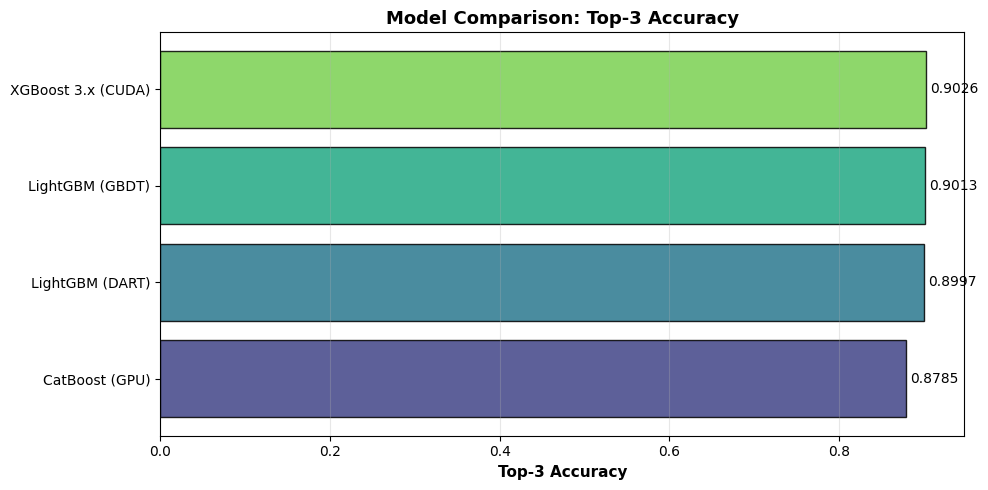

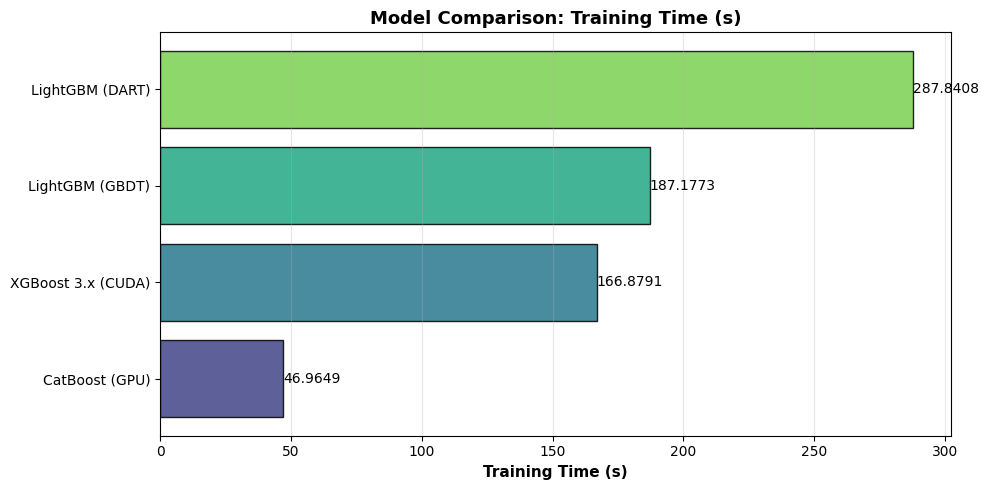

Best model: XGBoost 3.x (CUDA) (0.7387 Test Accuracy)


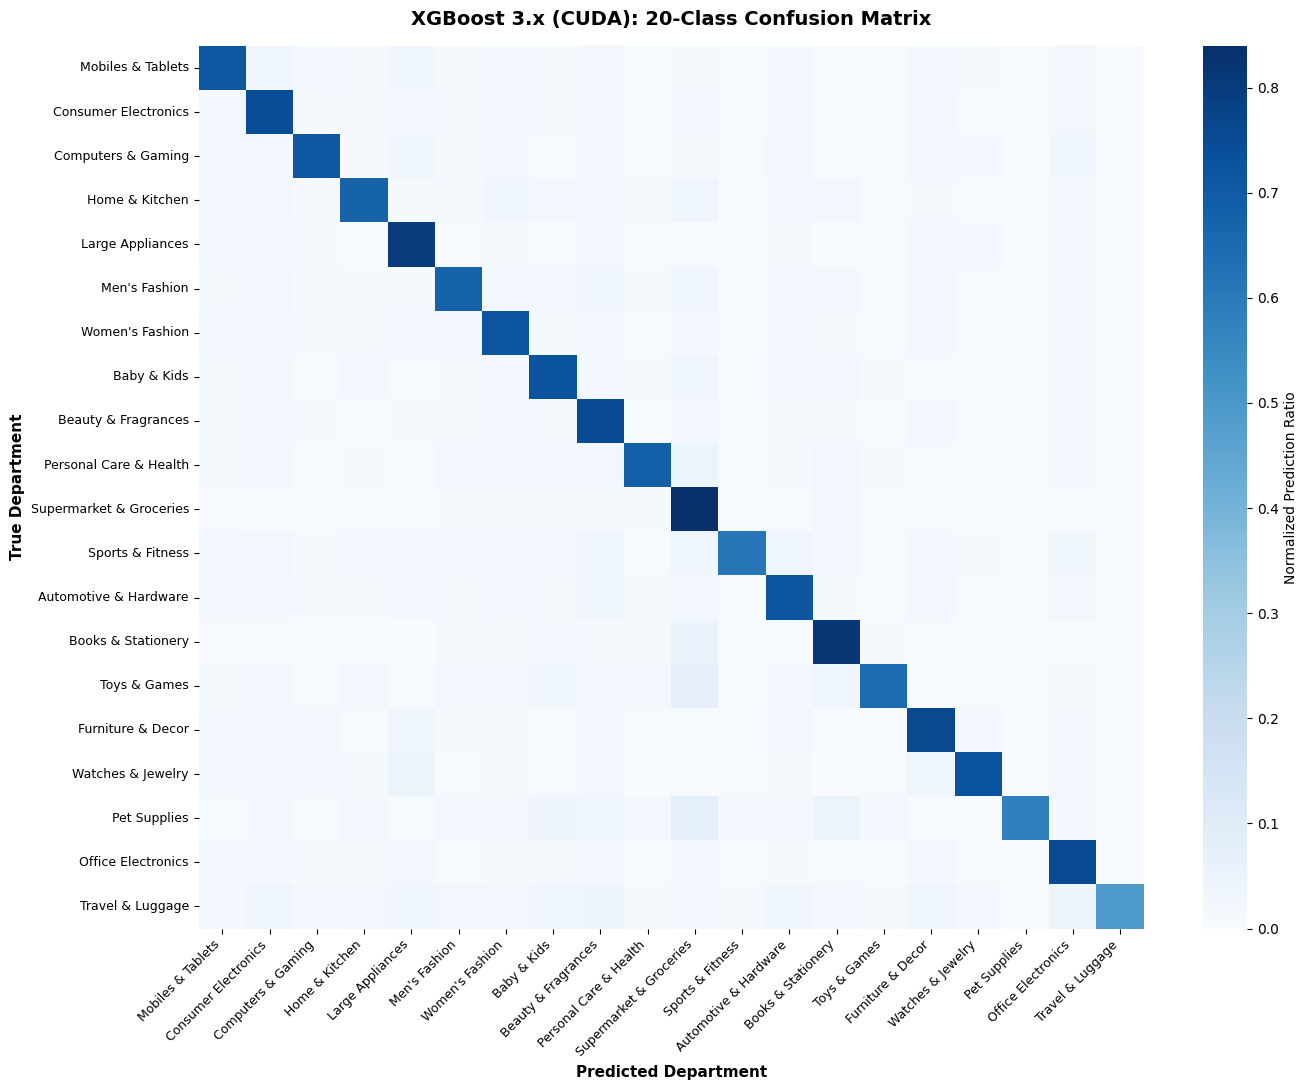

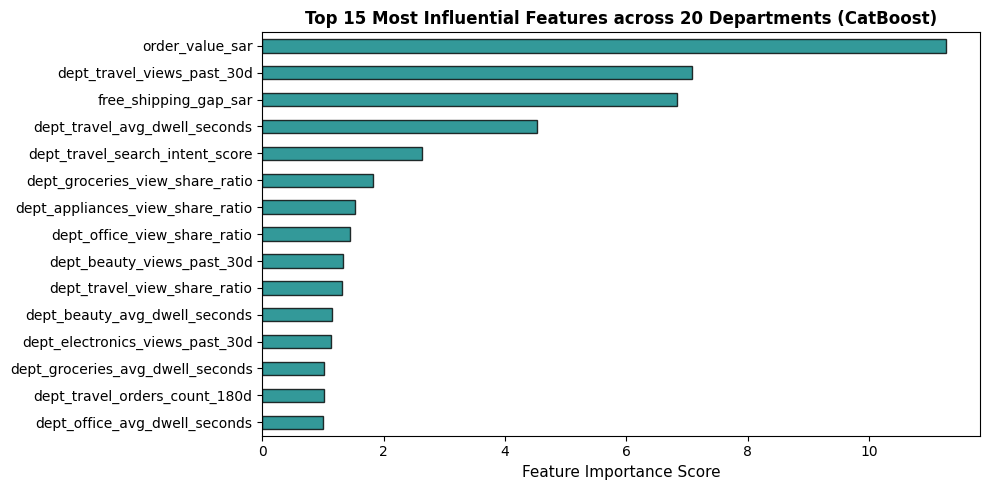

In [26]:
# ── Model comparisons ─────────────────────────────────────────────────────────
plot_metrics_comparison(all_results, metric_name='Top-3 Accuracy')
plot_metrics_comparison(all_results, metric_name='Training Time (s)')

# ── Confusion Matrix for the actual best model ────────────────────────────────
best_idx  = int(np.argmax([r['Top-1 Accuracy'] for r in all_results]))
best_name = all_results[best_idx]['Model']
print(f"Best model: {best_name} ({all_results[best_idx]['Top-1 Accuracy']:.4f} Test Accuracy)")

# Map index → predictions array
# Order: XGBoost, LightGBM GBDT, LightGBM DART, CatBoost
all_preds = [
    xgb_model.predict(X_test),
    lgb_model.predict(X_test),
    lgb_dart.predict(X_test),
    cat_pred
]
plot_confusion_matrix_20(
    y_test, all_preds[best_idx],
    class_names=DEPARTMENTS_EN,
    title=f"{best_name}: 20-Class Confusion Matrix"
)

# ── Feature Importance from CatBoost ──────────────────────────────────────────
fi = (
    pd.Series(cat_model.get_feature_importance(), index=X_train_cat.columns)
    .sort_values(ascending=False)
    .head(15)
)
plt.figure(figsize=(10, 5))
fi.plot(kind='barh', color='teal', edgecolor='black', alpha=0.8)
plt.title('Top 15 Most Influential Features across 20 Departments (CatBoost)',
          fontsize=12, fontweight='bold')
plt.xlabel('Feature Importance Score', fontsize=11)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 7. Master Summary: Architectural Decision Matrix

| Dimension | XGBoost 3.x | LightGBM | CatBoost |
|---|---|---|---|
| **Core Optimization** | 2nd-Order Newton Taylor expansion | 1st-Order gradient with GOSS | 2nd-Order with Ordered Permutations |
| **Tree Architecture** | Depth-wise (balanced) | Leaf-wise (best-first) | Oblivious (symmetric) |
| **Inference Mechanism** | Tree traversal | Tree traversal | **Bitwise integer lookup table** |
| **Categorical Handling** | Native `enable_categorical` (XGB 3.x) | Integer binning with Fisher splits | **Ordered Target Statistics (leak-free)** |
| **GPU Support** | Native CUDA (`device='cuda'`) | OpenCL / CUDA | **Native GPU (`task_type='GPU'`)** |
| **Early Stopping** | ✅ `early_stopping_rounds` in `fit()` | ✅ `lgb.early_stopping` callback | ✅ `early_stopping_rounds` in `fit()` |
| **Over-Specialization Fix** | Subsampling & L2 | **DART (Tree Dropout)** | Random strength regularizer |
| **Best Production Use** | Complex mixed tabular & GPU scaling | Huge datasets (>100k rows) with low RAM | Heavy categorical/text data & high robustness |